# Retail Performance Analytics

## Data Understanding

This notebook explores the structure and quality of the Online Retail dataset.

The objective is to identify data quality issues, understand the business context, and define the data cleaning strategy before performing business analysis.

---
### Project Roadmap

| Stage | Status |
|--------|--------|
| Business Understanding | ✅ Completed |
| Data Understanding | ✅ Completed |
| Data Cleaning | 🟡 Next |
| Business Analysis | ⏳ Planned |
| SQL Analysis | ⏳ Planned |
| Power BI Dashboard | ⏳ Planned |
| Executive Report | ⏳ Planned |

### Notebook Objectives

In this notebook we will:

- Load the dataset
- Explore its structure
- Assess data quality
- Identify inconsistencies
- Document business implications
- Define the cleaning strategy

#### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# Pandas display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

# Matplotlib default style
plt.style.use("default")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

#### Load Dataset

In [2]:
df = pd.read_excel("../data/raw/Online Retail.xlsx")

#### Dataset Preview

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


#### Observation

The initial preview confirms the dataset structure and provides a first view of the available variables.

Each record represents a retail transaction, including invoice information, product details, customer identification, pricing and country.

#### Dataset Structure

In [4]:
rows, columns = df.shape

print(f"Rows: {rows:,}")
print(f"Columns: {columns}")

Rows: 541,909
Columns: 8


#### Observation

The dataset contains **541,909 transaction records** and **8 variables** describing sales, products, customers and geographical information.

This volume of data is sufficient to support exploratory analysis, business intelligence reporting and KPI development.

#### Dataset Information

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


#### Observation

The dataset contains categorical, numerical and datetime variables, providing a comprehensive view of retail transactions.

The **InvoiceDate** column has been correctly recognized as a datetime data type, enabling time-based analyses without additional preprocessing.

The initial inspection also reveals two columns that require further attention during the data cleaning phase:

- **Description** contains **1,454 missing values**.
- **CustomerID** contains **135,080 missing values** (approximately **24.9%** of all records).

#### Statistical Summary

In [6]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


#### Observation

The statistical summary highlights several characteristics of the numerical variables.

Key observations include:

- The **Quantity** column contains negative values, indicating the presence of returns or stock adjustments.
- The **UnitPrice** column also includes negative values, suggesting accounting adjustments that require further investigation.
- The wide range of values in both **Quantity** and **UnitPrice** indicates the presence of potential outliers, which should be assessed before business analysis.

#### Missing Values

In [7]:
missing_values = df.isnull().sum()

missing_percentage = (
    missing_values / len(df) * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing (%)": missing_percentage
})

missing_summary = (
    missing_summary[missing_summary["Missing Values"] > 0]
    .sort_values("Missing Values", ascending=False)
)

display(missing_summary)

,Missing Values,Missing (%)
CustomerID,135080,24.93
Description,1454,0.27


#### Observation

The missing value analysis identified incomplete information in **2 of the 8 variables**.

- **CustomerID** contains **135,080 missing values (24.93%)**, representing nearly one quarter of all transactions. This pattern is commonly associated with anonymous customers in retail datasets and may limit customer-level analyses.

- **Description** contains **1,454 missing values (0.27%)**. Although the proportion is very small, missing product descriptions may affect product-level analyses and should be investigated during the data cleaning stage.

The remaining **six variables** contain no missing values, indicating that most of the dataset is complete and suitable for business analysis.

#### Business Impact

Missing **CustomerID** values reduce the ability to perform customer segmentation, repeat purchase analysis, customer retention analysis, and customer lifetime value (CLV) calculations.

Missing **Description** values may affect product categorization, product-level reporting, and sales analyses involving product descriptions.

#### Duplicate Records

In [8]:
duplicate_records = df.duplicated().sum()

duplicate_percentage = (
    duplicate_records / len(df) * 100
)

print(
    f"Duplicated records: {duplicate_records:,} "
    f"({duplicate_percentage:.2f}%)"
)

Duplicated records: 5,268 (0.97%)


##### Preview of duplicated records

In [9]:
df[df.duplicated()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


#### Observation

A total of **5,268 duplicated records (0.97%)** were identified in the dataset.

An initial inspection of the duplicated entries suggests that they require further investigation before any cleaning action is taken.

Although duplicated records represent less than **1%** of the dataset, it is important to determine whether they correspond to legitimate repeated transactions or duplicated entries.

#### Business Impact

If duplicated records do not represent legitimate business transactions, they may inflate transaction counts, sales volume and revenue calculations.

Validating these records is therefore essential before calculating KPIs or performing business analysis.

#### Decision

No duplicated records will be removed at this stage.

The duplicated entries will be investigated during the Data Cleaning phase before defining the appropriate treatment strategy.

#### Negative Quantity

In [10]:
negative_quantity = df[df["Quantity"] < 0]

negative_records = negative_quantity.shape[0]

negative_percentage = (
    negative_records / len(df) * 100
)

print(f"Negative transactions: {negative_records:,}")
print(f"Percentage: {negative_percentage:.2f}%")

Negative transactions: 10,624
Percentage: 1.96%


#### Observation

The dataset contains 10,624 transactions (1.96%) with negative quantity values.

Negative quantities are uncommon in retail sales and may indicate returns, cancelled orders or other operational adjustments.

At this stage, their exact business meaning is unknown and requires further investigation.

#### Investigating Negative Quantity Transactions

To better understand the nature of these records, the first transactions with negative quantities are displayed below.

In [11]:
negative_quantity.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


#### Observation

The first negative quantity records reveal an interesting pattern.

Several invoice numbers begin with the letter "C", while product descriptions and unit prices remain consistent with regular sales transactions.

This suggests that the invoice number may provide useful information about the nature of these transactions and should be investigated further.

#### Invoice Investigation

In [12]:
invoice_pattern = (
    negative_quantity["InvoiceNo"]
    .astype(str)
    .str.startswith("C")
)

invoice_summary = (
    invoice_pattern
    .value_counts()
    .rename_axis("Cancelled Invoice")
    .reset_index(name="Transactions")
)

invoice_summary["Percentage (%)"] = (
    invoice_summary["Transactions"]
    / invoice_summary["Transactions"].sum()
    * 100
).round(2)

display(invoice_summary)

,Cancelled Invoice,Transactions,Percentage (%)
0,True,9288,87.42
1,False,1336,12.58


#### Observation

The invoice pattern reveals that 87.42% of negative quantity transactions are associated with invoice numbers starting with the letter "C", while 12.58% do not follow this pattern.

This finding suggests that negative quantities are not generated by a single business process.

Most records are likely related to cancelled orders, whereas the remaining transactions require further investigation to determine their origin.

#### Business Impact

Treating all negative quantity records as standard sales transactions could distort revenue, sales volume and other business KPIs.

Understanding the reason behind these transactions is essential before defining the data cleaning strategy.

#### Decision
Negative quantity transactions will be classified according to their business meaning during the Data Cleaning phase instead of being removed indiscriminately.

#### Investigation of Non-Cancelled Negative Transactions

In [13]:
negative_quantity[
    ~negative_quantity["InvoiceNo"]
    .astype(str)
    .str.startswith("C")
].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom


#### Observation

A subset of negative quantity transactions does not have invoice numbers starting with **"C"**.

An initial inspection shows that these records also contain missing product descriptions, missing customer IDs and unit prices equal to zero.

Unlike cancelled orders, these transactions do not appear to represent customer purchases. Instead, they are more likely associated with internal operational activities, such as stock adjustments or inventory corrections.

Further investigation will be conducted during the Data Cleaning phase to determine the appropriate treatment for these records.

#### Business Impact

Including these operational records in sales analyses could distort revenue, product performance and inventory-related KPIs.

#### Decision

These transactions will be investigated separately during the Data Cleaning phase before determining whether they should be excluded from the analytical dataset.

#### Country Distribution

In [14]:
df["Country"].nunique()

38

In [15]:
df["Country"].value_counts()

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
                   ...  
Lithuania             35
Brazil                32
Czech Republic        30
Bahrain               19
Saudi Arabia          10
Name: count, Length: 38, dtype: int64

In [16]:
country_share = (
    df["Country"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
      .rename("Percentage (%)")
)

country_share.head()

Country
United Kingdom    91.43
Germany            1.75
France             1.58
EIRE               1.51
Spain              0.47
Name: Percentage (%), dtype: float64

#### Observation

The dataset contains transactions from **38 countries**, demonstrating that the retailer operates across multiple international markets.

However, the **United Kingdom accounts for approximately 91% of all transactions**, indicating a highly concentrated customer base.

Because of this concentration, overall business metrics are expected to be strongly influenced by customer behavior in the UK. International markets will therefore be analyzed separately in later stages of the project.

#### Date Range

In [17]:
df["InvoiceDate"].min(), df["InvoiceDate"].max()

(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:50:00'))

In [18]:
df["InvoiceDate"].dt.month_name().value_counts().sort_index()

InvoiceDate
April        29916
August       35284
December     68006
February     27707
January      35147
July         39518
June         36874
March        36748
May          37030
November     84711
October      60742
September    50226
Name: count, dtype: int64

#### Observation

The dataset covers transactions from **December 1, 2010** to **December 9, 2011**, providing approximately one year of retail activity.

This period is sufficient to evaluate sales trends, customer purchasing behavior, product performance and seasonal patterns.

It is important to note that **December 2011 is incomplete**, as the dataset ends on **December 9**. Therefore, monthly comparisons involving December should be interpreted with caution.

#### Monthly Transaction Distribution

In [19]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_transactions = (
    df.assign(Month=df["InvoiceDate"].dt.month_name())
      .groupby("Month")
      .size()
      .reindex(month_order)
)

In [20]:
monthly_transactions.to_frame(name="Transactions")

,Transactions
Month,
January,35147
February,27707
March,36748
April,29916
May,37030
June,36874
July,39518
August,35284
September,50226


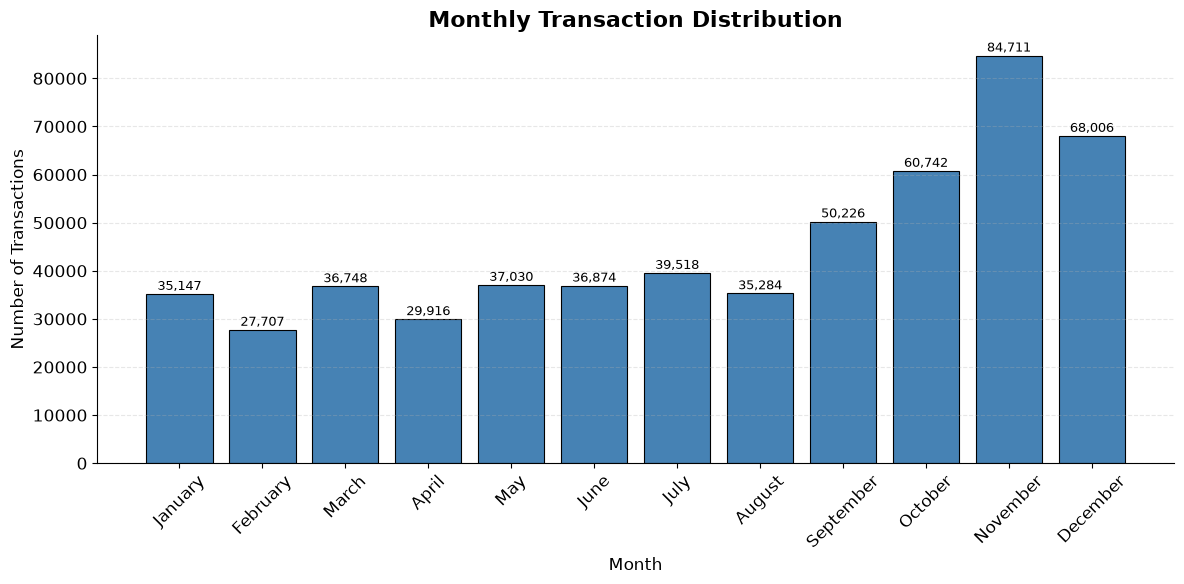

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    monthly_transactions.index,
    monthly_transactions.values,
    color="steelblue",
    edgecolor="black",
    linewidth=0.8
)

ax.set_title(
    "Monthly Transaction Distribution",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Month")
ax.set_ylabel("Number of Transactions")

ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.xticks(rotation=45)

for bar in bars:

    height = bar.get_height()

    ax.annotate(
        f"{int(height):,}",
        xy=(bar.get_x() + bar.get_width()/2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

#### Observation

Transaction activity is not evenly distributed throughout the year, revealing a clear seasonal pattern.

The number of transactions increases steadily from **September**, reaching its highest level in **November**, which is consistent with increased retail activity before the holiday season.

Although **December** also presents a high transaction volume, the dataset includes records only until **December 9, 2011**. Therefore, this month should not be directly compared with the others.

These findings indicate that seasonality should be considered during subsequent business analyses.

#### Customer Overview

In [22]:
identified_customers = df["CustomerID"].nunique()

anonymous_transactions = df["CustomerID"].isna().sum()

anonymous_percentage = (
    anonymous_transactions / len(df) * 100
)

print(f"Identified customers: {identified_customers:,}")
print(f"Anonymous transactions: {anonymous_transactions:,} ({anonymous_percentage:.2f}%)")

Identified customers: 4,372
Anonymous transactions: 135,080 (24.93%)


#### Observation

The dataset contains **4,372 unique identified customers**.

A total of **135,080 transactions (24.93%)** do not contain a CustomerID, may indicate anonymous purchases or incomplete customer records.

Customer-level analyses, such as customer segmentation and purchasing behavior, will therefore be performed using identified customers only.


#### Product Overview

In [23]:
unique_stockcodes = df["StockCode"].nunique()
unique_descriptions = df["Description"].nunique()

print(f"Unique Stock Codes: {unique_stockcodes:,}")
print(f"Unique Product Descriptions: {unique_descriptions:,}")

Unique Stock Codes: 4,070
Unique Product Descriptions: 4,223


#### Observation

The dataset contains **4,070 unique stock codes** and **4,223 unique product descriptions**.

The difference between these values suggests that some stock codes are associated with multiple descriptions or with non-merchandise records such as postage, discounts and accounting adjustments.


#### Decision

Non-product stock codes and inconsistent product descriptions will be investigated during the Data Cleaning phase before product-level analyses are performed.

#### Key Findings

- **541,909** retail transactions covering approximately one year of business operations.
- **4,372** identified customers across **38 countries**.
- Strong concentration of transactions in the **United Kingdom**.
- **4,070** stock codes and **4,223** product descriptions.
- Missing values limited to **CustomerID** and **Description**.
- **5,268** duplicated records requiring validation.
- **10,624** transactions with negative quantities.
- **2** accounting adjustments with negative unit prices.

### Conclusion

The dataset provides a strong foundation for retail analytics.

Although several data quality issues were identified, they are well understood and will be addressed systematically during the Data Cleaning phase.

The next notebook focuses on preparing a reliable analytical dataset for KPI calculation, SQL analysis and Power BI dashboard development.